# Doprinos 3 — Uporedna analiza tačnosti Faster-Whisper transkripcije za srpski i engleski jezik

## Cilj eksperimenta

Cilj eksperimenta je kontrolisano poređenje tačnosti Faster-Whisper transkripcije na engleskom i srpskom jeziku.

Za oba jezika korišćeno je po **5 sintetičkih gTTS audio zapisa** sa sadržajno odgovarajućim tekstovima. Time se izbegava direktno poređenje prirodnog govora jednog jezika sa sintetičkim govorom drugog jezika i smanjuje uticaj različitih uslova snimanja.

U svim testovima koristi se isti Faster-Whisper `base` model sa INT8 kvantizacijom na CPU-u. Za svaki snimak mere se **WER**, vreme transkripcije i **RTF**, dok se za konačno poređenje jezika koriste prosečan WER, medijana WER-a i corpus WER.


In [4]:
from pathlib import Path
import re
import time
import wave

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from faster_whisper import WhisperModel
from jiwer import wer


# ============================================================
# PUTANJE
# ============================================================

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

AUDIO_DIR = PROJECT_ROOT / "audio" / "03_srpski_engleski"
AUDIO_ENG_DIR = AUDIO_DIR / "engleski"
AUDIO_SR_DIR = AUDIO_DIR / "srpski"

REZULTATI_DIR = PROJECT_ROOT / "rezultati" / "03_poredjenje_srpski_engleski"
REZULTATI_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("AUDIO_ENG_DIR:", AUDIO_ENG_DIR)
print("AUDIO_SR_DIR:", AUDIO_SR_DIR)
print("REZULTATI_DIR:", REZULTATI_DIR)

PROJECT_ROOT: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR
AUDIO_ENG_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\audio\03_srpski_engleski\engleski
AUDIO_SR_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\audio\03_srpski_engleski\srpski
REZULTATI_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\03_poredjenje_srpski_engleski


In [5]:
# ============================================================
# REFERENTNI TEKSTOVI — ENGLESKI
# ============================================================

referenca_eng = [
    "Artificial intelligence represents a transformative branch of computer science dedicated to the creation of sophisticated systems capable of solving complex problems, making autonomous decisions, learning from vast amounts of data, and accurately understanding natural human speech in real-time environments.",
    "Automatic speech recognition technology enables the seamless conversion of spoken audio signals into structured written text, playing a crucial role in modern applications such as voice assistants, automated transcription services, and accessibility tools for individuals with disabilities.",
    "Deep learning based neural network models have significantly improved both the overall quality and the processing speed of modern speech recognition systems, allowing them to perform exceptionally well even in noisy environments and across various acoustic conditions.",
    "The Whisper model family, originally developed by OpenAI, utilizes large-scale neural networks trained on diverse multilingual datasets to enable highly accurate speech recognition, translation, and speaker alignment across dozens of different languages and dialects.",
    "Faster Whisper is an advanced and highly optimized implementation of the original Whisper architecture, built upon the CTranslate2 inference engine to deliver dramatic speed improvements and lower memory consumption without sacrificing transcription accuracy."
]


# ============================================================
# REFERENTNI TEKSTOVI — SRPSKI
# ============================================================

referenca_sr = [
    "Veštačka inteligencija predstavlja transformativnu granu računarskih nauka posvećenu kreiranju sofistiranih sistema sposobnih za rešavanje kompleksnih problema, donošenje autonomnih odluka, učenje iz ogromnih količina podataka i tačno razumevanje prirodnog ljudskog govora u okruženjima u realnom vremenu.",
    "Tehnologija automatskog prepoznavanja govora omogućava besprekornu konverziju izgovorenih zvučnih signala u strukturirani pisani tekst, igrajući ključnu ulogu u savremenim aplikacijama kao što su glasovni asistenti, usluge automatske transkripcije i alati za pristupačnost osobama sa invaliditetom.",
    "Modeli neuronskih mreža zasnovani na dubokom učenju značajno su poboljšali i ukupni kvalitet i brzinu obrade savremenih sistema za prepoznavanje govora, omogućavajući im da izuzetno dobro funkcionišu čak i u bučnim okruženjima i u različitim akustičkim uslovima.",
    "Porodica modela Whisper, koju je originalno razvio OpenAI, koristi neuronske mreže velikog obima trenirane na raznovrsnim višejezičkim skupovima podataka kako bi omogućila visoko precizno prepoznavanje govora, prevođenje i usklađivanje govornika na desetinama različitih jezika i dijalekata.",
    "Faster Whisper je napredna i visoko optimizovana implementacija originalne Whisper arhitekture, sagrađena na mašini za zaključivanje CTranslate2 radi pružanja dramatičnih poboljšanja brzine i manje potrošnje memorije bez žrtvovanja tačnosti transkripcije."
]

In [6]:
# ============================================================
# AUDIO FAJLOVI
# ============================================================

audio_eng = [
    AUDIO_ENG_DIR / "govor_p1_gtts.wav",
    AUDIO_ENG_DIR / "govor_p2_gtts.wav",
    AUDIO_ENG_DIR / "govor_p3_gtts.wav",
    AUDIO_ENG_DIR / "govor_p4_gtts.wav",
    AUDIO_ENG_DIR / "govor_p5_gtts.wav"
]

audio_sr = [
    AUDIO_SR_DIR / "govor_sr_p1_gtts.wav",
    AUDIO_SR_DIR / "govor_sr_p2_gtts.wav",
    AUDIO_SR_DIR / "govor_sr_p3_gtts.wav",
    AUDIO_SR_DIR / "govor_sr_p4_gtts.wav",
    AUDIO_SR_DIR / "govor_sr_p5_gtts.wav"
]


# ============================================================
# PROVERA POSTOJANJA FAJLOVA
# ============================================================

svi_fajlovi = audio_eng + audio_sr

for fajl in svi_fajlovi:
    if not fajl.exists():
        raise FileNotFoundError(
            f"Audio fajl nije pronađen: {fajl}"
        )

print(f"Sva {len(svi_fajlovi)} audio fajla su pronađena.")
print(f"Engleski: {len(audio_eng)}")
print(f"Srpski: {len(audio_sr)}")

Sva 10 audio fajla su pronađena.
Engleski: 5
Srpski: 5


In [7]:
# ============================================================
# POMOĆNE FUNKCIJE
# ============================================================

def normalizuj_tekst(tekst):
    tekst = tekst.lower().strip()

    tekst = re.sub(
        r"[^\w\sčćžšđ]",
        " ",
        tekst,
        flags=re.UNICODE
    )

    tekst = re.sub(
        r"\s+",
        " ",
        tekst
    ).strip()

    return tekst


def izracunaj_wer(referenca, hipoteza):
    return wer(
        normalizuj_tekst(referenca),
        normalizuj_tekst(hipoteza)
    )


def trajanje_wav(putanja):
    with wave.open(str(putanja), "rb") as f:
        return f.getnframes() / float(f.getframerate())

In [8]:
# ============================================================
# MODEL
# ============================================================

model = WhisperModel(
    "base",
    device="cpu",
    compute_type="int8"
)

print("Faster-Whisper base INT8 je učitan.")

Faster-Whisper base INT8 je učitan.


## Metodologija

Engleski i srpski audio zapisi obrađuju se istim Faster-Whisper `base` INT8 modelom. Prilikom transkripcije eksplicitno se zadaje odgovarajući jezik (`en` ili `sr`), dok ostali uslovi izvršavanja ostaju isti.

Generisani transkript se pre izračunavanja WER-a normalizuje uklanjanjem interpunkcije, razlikovanja velikih i malih slova i suvišnih razmaka.

Pored WER-a, meri se vreme transkripcije i računa Real-Time Factor (RTF) kao odnos vremena obrade i trajanja audio zapisa. Vrednost RTF manja od 1 označava da se transkripcija izvršava brže od realnog trajanja snimka.


In [9]:
# ============================================================
# ENGLESKI JEZIK
# ============================================================

rezultati_eng = []


for i, (fajl, referenca) in enumerate(
    zip(audio_eng, referenca_eng),
    start=1
):

    trajanje = trajanje_wav(fajl)

    start = time.perf_counter()

    segments, info = model.transcribe(
        str(fajl),
        language="en"
    )

    transkript = " ".join(
        segment.text.strip()
        for segment in segments
    ).strip()

    vreme = time.perf_counter() - start

    greska = izracunaj_wer(
        referenca,
        transkript
    )

    rtf = vreme / trajanje


    rezultati_eng.append({
        "Par": i,
        "Jezik": "engleski",
        "Kod jezika": "en",
        "Audio": fajl.name,
        "Trajanje [s]": round(trajanje, 3),
        "Vreme [s]": round(vreme, 3),
        "RTF": round(rtf, 4),
        "WER": round(greska, 4),
        "WER [%]": round(greska * 100, 2),
        "Referenca": referenca,
        "Transkript": transkript
    })


    print("=" * 90)
    print(f"ENGLESKI — PAR {i}")
    print("Audio:", fajl.name)
    print(f"Trajanje: {trajanje:.2f} s")
    print(f"Vreme: {vreme:.2f} s")
    print(f"RTF: {rtf:.3f}")
    print(f"WER: {greska * 100:.2f}%")
    print("REFERENCA:")
    print(referenca)
    print("TRANSKRIPT:")
    print(transkript)


df_eng = pd.DataFrame(rezultati_eng)

ENGLESKI — PAR 1
Audio: govor_p1_gtts.wav
Trajanje: 23.23 s
Vreme: 1.55 s
RTF: 0.067
WER: 0.00%
REFERENCA:
Artificial intelligence represents a transformative branch of computer science dedicated to the creation of sophisticated systems capable of solving complex problems, making autonomous decisions, learning from vast amounts of data, and accurately understanding natural human speech in real-time environments.
TRANSKRIPT:
Artificial intelligence represents a transformative branch of computer science dedicated to the creation of sophisticated systems capable of solving complex problems, making autonomous decisions, learning from vast amounts of data, and accurately understanding natural human speech in real-time environments.
ENGLESKI — PAR 2
Audio: govor_p2_gtts.wav
Trajanje: 22.15 s
Vreme: 1.56 s
RTF: 0.071
WER: 2.70%
REFERENCA:
Automatic speech recognition technology enables the seamless conversion of spoken audio signals into structured written text, playing a crucial role in mode

## Rezultati za engleski jezik

Faster-Whisper `base` INT8 ostvario je veoma nizak WER na svih pet sintetičkih engleskih snimaka. Pojedinačne WER vrednosti iznose **0,00%, 2,70%, 0,00%, 5,71% i 9,09%**.

Na dva od pet snimaka transkript se nakon primenjene normalizacije potpuno poklapa sa referentnim tekstom, odnosno WER iznosi **0%**. Najveća pojedinačna greška zabeležena je na petom snimku i iznosi **9,09%**.

Rezultati ukazuju da korišćena konfiguracija modela veoma precizno transkribuje engleski sintetički govor iz ovog test skupa.


In [10]:
# ============================================================
# SRPSKI JEZIK
# ============================================================

rezultati_sr = []


for i, (fajl, referenca) in enumerate(
    zip(audio_sr, referenca_sr),
    start=1
):

    trajanje = trajanje_wav(fajl)

    start = time.perf_counter()

    segments, info = model.transcribe(
        str(fajl),
        language="sr"
    )

    transkript = " ".join(
        segment.text.strip()
        for segment in segments
    ).strip()

    vreme = time.perf_counter() - start

    greska = izracunaj_wer(
        referenca,
        transkript
    )

    rtf = vreme / trajanje


    rezultati_sr.append({
        "Par": i,
        "Jezik": "srpski",
        "Kod jezika": "sr",
        "Audio": fajl.name,
        "Trajanje [s]": round(trajanje, 3),
        "Vreme [s]": round(vreme, 3),
        "RTF": round(rtf, 4),
        "WER": round(greska, 4),
        "WER [%]": round(greska * 100, 2),
        "Referenca": referenca,
        "Transkript": transkript
    })


    print("=" * 90)
    print(f"SRPSKI — PAR {i}")
    print("Audio:", fajl.name)
    print(f"Trajanje: {trajanje:.2f} s")
    print(f"Vreme: {vreme:.2f} s")
    print(f"RTF: {rtf:.3f}")
    print(f"WER: {greska * 100:.2f}%")
    print("REFERENCA:")
    print(referenca)
    print("TRANSKRIPT:")
    print(transkript)


df_sr = pd.DataFrame(rezultati_sr)

SRPSKI — PAR 1
Audio: govor_sr_p1_gtts.wav
Trajanje: 26.54 s
Vreme: 2.66 s
RTF: 0.100
WER: 37.14%
REFERENCA:
Veštačka inteligencija predstavlja transformativnu granu računarskih nauka posvećenu kreiranju sofistiranih sistema sposobnih za rešavanje kompleksnih problema, donošenje autonomnih odluka, učenje iz ogromnih količina podataka i tačno razumevanje prirodnog ljudskog govora u okruženjima u realnom vremenu.
TRANSKRIPT:
Beštačka inteligencija predstavlja transformativnu granu računarskih nauka po svećenu kreiranju. Sofisti ranih sistema sposodnih zarešavanje kompleksnih problema. Donošenje autonomnih odluka, učenje i zogromnih količina podata ka i tačno razumevanje prirodnog ljudskog govora, okruženjima u. Realnom vremenu.
SRPSKI — PAR 2
Audio: govor_sr_p2_gtts.wav
Trajanje: 25.94 s
Vreme: 3.74 s
RTF: 0.144
WER: 37.14%
REFERENCA:
Tehnologija automatskog prepoznavanja govora omogućava besprekornu konverziju izgovorenih zvučnih signala u strukturirani pisani tekst, igrajući ključnu ul

## Rezultati za srpski jezik

Na odgovarajućim srpskim gTTS snimcima zabeležena je znatno veća greška transkripcije. Pojedinačne WER vrednosti iznose **37,14%, 37,14%, 43,24%, 50,00% i 53,33%**.

Za razliku od engleskog skupa, nijedan srpski snimak nije transkribovan sa veoma niskim WER-om. Greške uključuju pogrešno prepoznate reči, nepravilno razdvajanje reči i pogrešno prepoznavanje stručnih izraza i naziva.

Rezultati ovog kontrolisanog skupa pokazuju da ista `base` INT8 konfiguracija ima znatno veću grešku pri transkripciji srpskog nego engleskog sintetičkog govora.


In [11]:
# ============================================================
# OBJEDINJENI DETALJNI REZULTATI
# ============================================================

df_detaljno = pd.concat(
    [df_eng, df_sr],
    ignore_index=True
)


display(
    df_detaljno[
        [
            "Par",
            "Jezik",
            "Audio",
            "Trajanje [s]",
            "Vreme [s]",
            "RTF",
            "WER [%]"
        ]
    ]
)

,Par,Jezik,Audio,Trajanje [s],Vreme [s],RTF,WER [%]
0,1,engleski,govor_p1_gtts.wav,23.232,1.546,0.0665,0.00
1,2,engleski,govor_p2_gtts.wav,22.152,1.563,0.0706,2.70
2,3,engleski,govor_p3_gtts.wav,19.872,1.459,0.0734,0.00
3,4,engleski,govor_p4_gtts.wav,22.080,1.521,0.0689,5.71
4,5,engleski,govor_p5_gtts.wav,19.512,1.995,0.1022,9.09
5,1,srpski,govor_sr_p1_gtts.wav,26.544,2.663,0.1003,37.14
6,2,srpski,govor_sr_p2_gtts.wav,25.944,3.739,0.1441,37.14
7,3,srpski,govor_sr_p3_gtts.wav,23.448,3.373,0.1439,43.24
8,4,srpski,govor_sr_p4_gtts.wav,25.920,2.465,0.0951,50.00
9,5,srpski,govor_sr_p5_gtts.wav,21.528,1.897,0.0881,53.33


In [12]:
# ============================================================
# MACRO PROSEK I MEDIJANA WER-a
# ============================================================

rezime_jezici = (
    df_detaljno
    .groupby("Jezik")
    .agg(
        Broj_snimaka=("Audio", "count"),
        Prosecno_trajanje=("Trajanje [s]", "mean"),
        Prosecno_vreme=("Vreme [s]", "mean"),
        Prosecan_RTF=("RTF", "mean"),
        Prosecan_WER=("WER [%]", "mean"),
        Medijana_WER=("WER [%]", "median")
    )
    .reset_index()
    .round(3)
)


print("=" * 90)
print("POREĐENJE SRPSKOG I ENGLESKOG JEZIKA")
print("=" * 90)

display(rezime_jezici)

POREĐENJE SRPSKOG I ENGLESKOG JEZIKA


,Jezik,Broj_snimaka,Prosecno_trajanje,Prosecno_vreme,Prosecan_RTF,Prosecan_WER,Medijana_WER
0,engleski,5,21.370,1.617,0.076,3.50,2.70
1,srpski,5,24.677,2.827,0.114,44.17,43.24


## Analiza ukupnih rezultata

Zbirni rezultati pokazuju veliku razliku u tačnosti transkripcije između dva testirana jezika.

Za engleski jezik prosečan WER iznosi samo **3,50%**, dok je medijana **2,70%**. Za srpski jezik prosečan WER iznosi **44,17%**, uz medijanu od **43,24%**. Apsolutna razlika prosečnih WER vrednosti iznosi **40,67 procentnih poena**.

Rezultati vremena izvršavanja takođe pokazuju razliku. Prosečno vreme transkripcije iznosi **1,617 s** za engleski i **2,827 s** za srpski. Prosečan RTF iznosi **0,076** za engleski i **0,114** za srpski.

Obe RTF vrednosti su znatno manje od 1, pa se oba jezika obrađuju višestruko brže od realnog vremena. Ipak, u ovom eksperimentu srpski skup zahteva približno **50% veći prosečan RTF** od engleskog.

Najizraženija razlika, međutim, nije u brzini već u kvalitetu transkripcije: na korišćenom kontrolisanom gTTS skupu `base` INT8 model postiže višestruko manju grešku na engleskom nego na srpskom jeziku.


In [13]:
# ============================================================
# CORPUS WER
# ============================================================
#
# Za razliku od prosečnog WER-a po fajlu, corpus WER tretira
# svih 5 referenci jednog jezika kao jedan zajednički korpus.
# Duži tekstovi zato prirodno imaju veću težinu.


ref_eng_corpus = " ".join(
    normalizuj_tekst(x)
    for x in df_eng["Referenca"]
)

hyp_eng_corpus = " ".join(
    normalizuj_tekst(x)
    for x in df_eng["Transkript"]
)


ref_sr_corpus = " ".join(
    normalizuj_tekst(x)
    for x in df_sr["Referenca"]
)

hyp_sr_corpus = " ".join(
    normalizuj_tekst(x)
    for x in df_sr["Transkript"]
)


corpus_wer_eng = wer(
    ref_eng_corpus,
    hyp_eng_corpus
)

corpus_wer_sr = wer(
    ref_sr_corpus,
    hyp_sr_corpus
)


print(f"Corpus WER — engleski: {corpus_wer_eng * 100:.2f}%")
print(f"Corpus WER — srpski:    {corpus_wer_sr * 100:.2f}%")

Corpus WER — engleski: 3.30%
Corpus WER — srpski:    43.93%


## Analiza corpus WER-a

Pored prosečnog WER-a po pojedinačnim snimcima, izračunat je i corpus WER, pri čemu se svih pet referenci jednog jezika posmatra kao jedan zajednički tekst. Na ovaj način duži tekstovi imaju proporcionalno veći uticaj na konačni rezultat.

Corpus WER za engleski jezik iznosi **3,30%**, dok za srpski iznosi **43,93%**. Ove vrednosti su veoma bliske prosečnim WER vrednostima po fajlu od **3,50%** i **44,17%**.

Sličnost macro i corpus rezultata pokazuje da uočena razlika između jezika nije posledica samo jednog kratkog ili dugog audio zapisa, već je prisutna kroz kompletan mali test skup.


In [14]:
# ============================================================
# ZAVRŠNA TABELA SA MACRO I CORPUS WER-om
# ============================================================

macro_eng = df_eng["WER [%]"].mean()
macro_sr = df_sr["WER [%]"].mean()

medijana_eng = df_eng["WER [%]"].median()
medijana_sr = df_sr["WER [%]"].median()


tabela_doprinos3 = pd.DataFrame({
    "Jezik": [
        "engleski",
        "srpski"
    ],
    "Broj snimaka": [
        len(df_eng),
        len(df_sr)
    ],
    "Prosečan WER [%]": [
        round(macro_eng, 2),
        round(macro_sr, 2)
    ],
    "Medijana WER [%]": [
        round(medijana_eng, 2),
        round(medijana_sr, 2)
    ],
    "Corpus WER [%]": [
        round(corpus_wer_eng * 100, 2),
        round(corpus_wer_sr * 100, 2)
    ],
    "Prosečan RTF": [
        round(df_eng["RTF"].mean(), 3),
        round(df_sr["RTF"].mean(), 3)
    ]
})


display(tabela_doprinos3)

,Jezik,Broj snimaka,Prosečan WER [%],Medijana WER [%],Corpus WER [%],Prosečan RTF
0,engleski,5,3.50,2.70,3.30,0.076
1,srpski,5,44.17,43.24,43.93,0.114


In [15]:
# ============================================================
# POREĐENJE ODGOVARAJUĆIH PAROVA
# ============================================================

poredjenje_parova = pd.DataFrame({
    "Par": [1, 2, 3, 4, 5],
    "WER EN [%]": df_eng["WER [%]"].values,
    "WER SR [%]": df_sr["WER [%]"].values
})


poredjenje_parova["Razlika SR-EN [pp]"] = (
    poredjenje_parova["WER SR [%]"]
    -
    poredjenje_parova["WER EN [%]"]
)


poredjenje_parova = poredjenje_parova.round(2)

print("WER PO ODGOVARAJUĆIM EN/SR PAROVIMA")
display(poredjenje_parova)

WER PO ODGOVARAJUĆIM EN/SR PAROVIMA


,Par,WER EN [%],WER SR [%],Razlika SR-EN [pp]
0,1,0.00,37.14,37.14
1,2,2.70,37.14,34.44
2,3,0.00,43.24,43.24
3,4,5.71,50.00,44.29
4,5,9.09,53.33,44.24


## Analiza odgovarajućih EN/SR parova

Poređenje odgovarajućih parova pokazuje da je WER srpske verzije veći u **svih pet testiranih parova**.

Razlika između srpskog i engleskog WER-a iznosi **37,14**, **34,44**, **43,24**, **44,29** i **44,24 procentna poena** za parove 1–5.

Činjenica da je ista tendencija prisutna u svakom od pet parova dodatno potvrđuje da velika ukupna razlika nije izazvana samo jednim ekstremnim rezultatom. U okviru ovog kontrolisanog sintetičkog skupa Faster-Whisper `base` INT8 dosledno ostvaruje niži WER na engleskim nego na odgovarajućim srpskim snimcima.


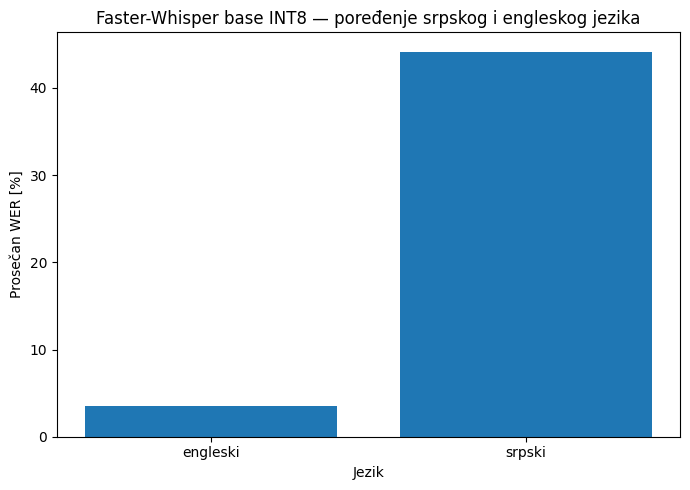

In [16]:
# ============================================================
# GRAFIK — PROSEČAN WER
# ============================================================

plt.figure(figsize=(7, 5))

plt.bar(
    tabela_doprinos3["Jezik"],
    tabela_doprinos3["Prosečan WER [%]"]
)

plt.xlabel("Jezik")
plt.ylabel("Prosečan WER [%]")

plt.title(
    "Faster-Whisper base INT8 — poređenje srpskog i engleskog jezika"
)

plt.tight_layout()
plt.show()

## Komentar grafičkog poređenja WER-a

Grafički prikaz jasno pokazuje razliku u tačnosti između dva jezika. Engleski snimci imaju WER u rasponu od **0,00% do 9,09%**, dok se kod srpskih snimaka WER kreće od **37,14% do 53,33%**.

Između ova dva raspona nema preklapanja: čak je i najlošiji rezultat na engleskom skupu (**9,09%**) znatno bolji od najboljeg rezultata na srpskom skupu (**37,14%**).

Takva raspodela rezultata pokazuje da razlika nije vidljiva samo u prosečnim vrednostima, već i na nivou svakog pojedinačnog testiranog para.


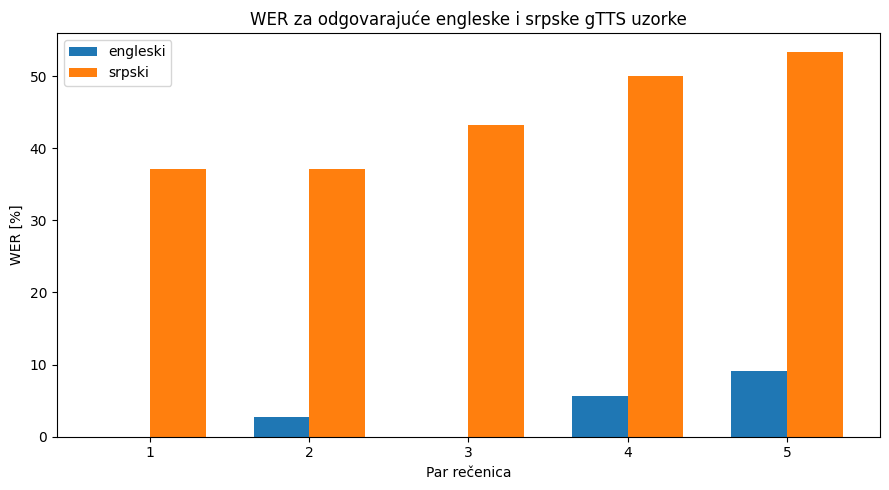

In [17]:
# ============================================================
# GRAFIK — WER PO PAROVIMA
# ============================================================

x = np.arange(len(poredjenje_parova))
sirina = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - sirina / 2,
    poredjenje_parova["WER EN [%]"],
    sirina,
    label="engleski"
)

plt.bar(
    x + sirina / 2,
    poredjenje_parova["WER SR [%]"],
    sirina,
    label="srpski"
)

plt.xlabel("Par rečenica")
plt.ylabel("WER [%]")
plt.title("WER za odgovarajuće engleske i srpske gTTS uzorke")

plt.xticks(
    x,
    poredjenje_parova["Par"]
)

plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# ZAVRŠNI REZIME EKSPERIMENTA 03
# ============================================================

razlika_macro = macro_sr - macro_eng
odnos_macro = macro_sr / macro_eng if macro_eng > 0 else np.nan


print("=" * 90)
print("ZAVRŠNI REZULTATI — SRPSKI VS ENGLESKI")
print("=" * 90)

print(f"Model: Faster-Whisper base INT8")
print(f"Broj EN snimaka: {len(df_eng)}")
print(f"Broj SR snimaka: {len(df_sr)}")

print("\nENGLESKI:")
print(f"  Prosečan WER: {macro_eng:.2f}%")
print(f"  Medijana WER: {medijana_eng:.2f}%")
print(f"  Corpus WER: {corpus_wer_eng * 100:.2f}%")
print(f"  Prosečan RTF: {df_eng['RTF'].mean():.3f}")

print("\nSRPSKI:")
print(f"  Prosečan WER: {macro_sr:.2f}%")
print(f"  Medijana WER: {medijana_sr:.2f}%")
print(f"  Corpus WER: {corpus_wer_sr * 100:.2f}%")
print(f"  Prosečan RTF: {df_sr['RTF'].mean():.3f}")

print(
    f"\nRazlika prosečnog WER-a SR - EN: "
    f"{razlika_macro:+.2f} procentnih poena"
)

if not np.isnan(odnos_macro):
    print(
        f"Odnos prosečnog WER-a SR / EN: "
        f"{odnos_macro:.2f}x"
    )

ZAVRŠNI REZULTATI — SRPSKI VS ENGLESKI
Model: Faster-Whisper base INT8
Broj EN snimaka: 5
Broj SR snimaka: 5

ENGLESKI:
  Prosečan WER: 3.50%
  Medijana WER: 2.70%
  Corpus WER: 3.30%
  Prosečan RTF: 0.076

SRPSKI:
  Prosečan WER: 44.17%
  Medijana WER: 43.24%
  Corpus WER: 43.93%
  Prosečan RTF: 0.114

Razlika prosečnog WER-a SR - EN: +40.67 procentnih poena
Odnos prosečnog WER-a SR / EN: 12.62x


In [19]:
# ============================================================
# ČUVANJE REZULTATA
# ============================================================

df_detaljno.to_csv(
    REZULTATI_DIR / "03_sr_en_svi_rezultati.csv",
    index=False,
    encoding="utf-8-sig"
)


tabela_doprinos3.to_csv(
    REZULTATI_DIR / "03_sr_en_rezime.csv",
    index=False,
    encoding="utf-8-sig"
)


poredjenje_parova.to_csv(
    REZULTATI_DIR / "03_sr_en_po_parovima.csv",
    index=False,
    encoding="utf-8-sig"
)


rezime_jezici.to_csv(
    REZULTATI_DIR / "03_sr_en_statistika.csv",
    index=False,
    encoding="utf-8-sig"
)


print("Rezultati su sačuvani u:")
print(REZULTATI_DIR)

Rezultati su sačuvani u:
D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\03_poredjenje_srpski_engleski


## Zaključak eksperimenta

Eksperiment je pokazao izraženu razliku u tačnosti Faster-Whisper `base` INT8 modela između engleskog i srpskog jezika na korišćenom kontrolisanom skupu sintetičkog govora.

Prosečan WER za engleski iznosio je **3,50%**, a corpus WER **3,30%**. Za srpski jezik odgovarajuće vrednosti iznosile su **44,17%** i **43,93%**. Razlika prosečnih WER vrednosti iznosi **40,67 procentnih poena**, pri čemu je srpski WER bio veći u svakom od pet odgovarajućih EN/SR parova.

Model je oba jezika obrađivao brže od realnog vremena, sa prosečnim RTF-om od **0,076** za engleski i **0,114** za srpski. Zbog toga je glavna uočena razlika između jezika bila u tačnosti transkripcije, a ne u mogućnosti izvršavanja u realnom vremenu.

Rezultati pokazuju da korišćeni Faster-Whisper `base` INT8 model na ovom test skupu znatno preciznije transkribuje engleski nego srpski sintetički govor. Ipak, zaključak treba ograničiti na korišćeni skup od **5 gTTS snimaka po jeziku**. Eksperiment ne predstavlja opštu procenu svih govornika i svih uslova govora, već kontrolisanu demonstraciju razlike u performansama modela između dva jezika pod istim tipom sintetičkog govora.
